# TASK 2: Exploratory Data Analysis (EDA)

"""Questions to Ask Before Analysis
 Before starting the analysis, ask questions like:
1.Which industry has the highest number of companies?
2.Which company generates the highest revenue?
3.Is there a relationship between revenue and number of employees?
4.Which headquarters location appears most frequently?
5.Are certain industries dominating the market?
6.Are there any missing or inconsistent values in the dataset?
"""

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/princ/Documents/project/outputs/Companies.csv")
df.head()

,Rank,Name,Industry,Revenue (USD billions),Employees,Headquarters
0,1,Walmart,Retail,"6,80,985",5.10%,"21,00,000"
1,2,Amazon,Retail and cloud computing,"6,37,959",11.00%,"15,56,000"
2,3,UnitedHealth Group,Healthcare,"4,00,278",7.70%,"4,00,000"
3,4,Apple,Technology,"3,91,035",2.00%,"1,64,000"
4,5,CVS Health,Healthcare,"3,72,809",4.20%,"2,59,500"


# Explore Data Structure

In [3]:
# View Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Rank                    100 non-null    int64 
 1   Name                    100 non-null    object
 2   Industry                100 non-null    object
 3   Revenue (USD billions)  100 non-null    object
 4   Employees               100 non-null    object
 5   Headquarters            100 non-null    object
dtypes: int64(1), object(5)
memory usage: 4.8+ KB


In [4]:
#Check Shape of Dataset
df.shape

(100, 6)

In [5]:
#View Column Names
df.columns

Index(['Rank', 'Name', 'Industry', 'Revenue (USD billions)', 'Employees',
       'Headquarters'],
      dtype='object')

In [6]:
#Check Data Types
df.dtypes

Rank                       int64
Name                      object
Industry                  object
Revenue (USD billions)    object
Employees                 object
Headquarters              object
dtype: object

# Statistical Summary


In [7]:
df.describe()

,Rank
count,100.000000
mean,50.500000
std,29.011492
min,1.000000
25%,25.750000
50%,50.500000
75%,75.250000
max,100.000000


In [8]:
#Check Missing Values
df.isnull().sum()

Rank                      0
Name                      0
Industry                  0
Revenue (USD billions)    0
Employees                 0
Headquarters              0
dtype: int64

In [9]:
#Detect Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [10]:
#Industry-wise Company Count
df['Industry'].value_counts()

Industry
Financials                             16
Retail                                  9
Technology                              9
Petroleum                               9
Healthcare                              7
Insurance                               6
Pharmaceutical                          5
Aerospace and defense                   4
Airline                                 3
Technology and cloud computing          3
Food processing                         3
Telecommunications                      3
Transportation                          2
Pharmaceutical industry                 2
Beverage                                2
Automotive                              2
Health insurance                        2
Retail and cloud computing              1
Media                                   1
Automotive and energy                   1
Food industry                           1
Consumer products manufacturing         1
Conglomerate and telecommunications     1
Machinery                

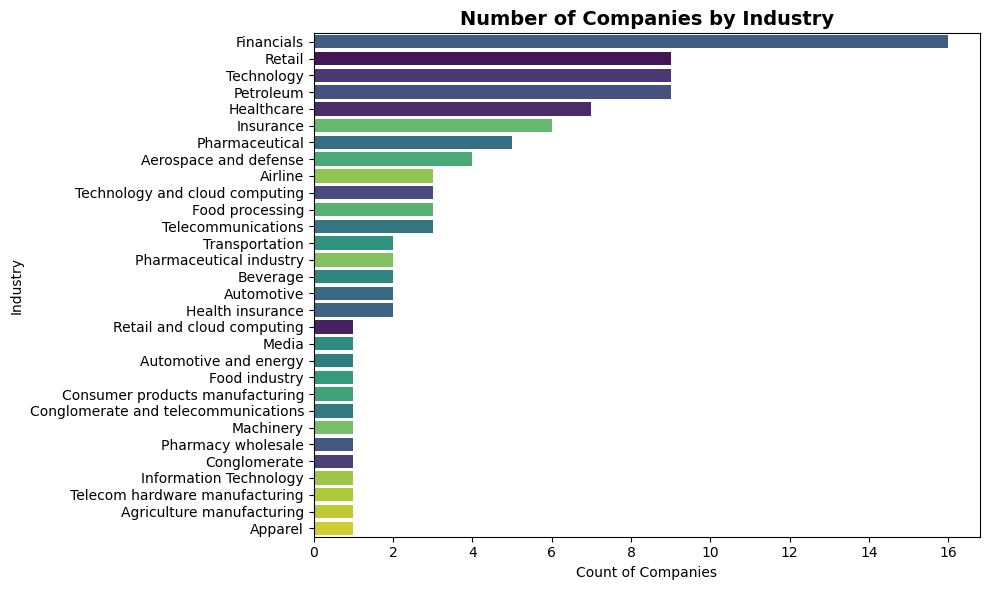

In [19]:
plt.figure(figsize=(10, 6))
# Added: hue='Industry' and legend=False
sns.countplot(
    data=df, 
    y='Industry', 
    order=df['Industry'].value_counts().index, 
    hue='Industry', 
    palette='viridis', 
    legend=False
)
plt.title('Number of Companies by Industry', fontsize=14, fontweight='bold')
plt.xlabel('Count of Companies')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

In [12]:
#Top 10 Companies by Revenue
top10 = df.sort_values(by='Revenue (USD billions)', ascending=False).head(10)
print(top10[['Name', 'Revenue (USD billions)']])

                      Name Revenue (USD billions)
41            StoneX Group                 99,888
42                   Tesla                 97,690
43       Dell Technologies                 95,567
44                 PepsiCo                 91,854
45             Walt Disney                 91,361
46   United Parcel Service                 91,070
47       Johnson & Johnson                 88,821
48                   FedEx                 87,693
49  Archer Daniels Midland                 85,530
50        Procter & Gamble                 84,039


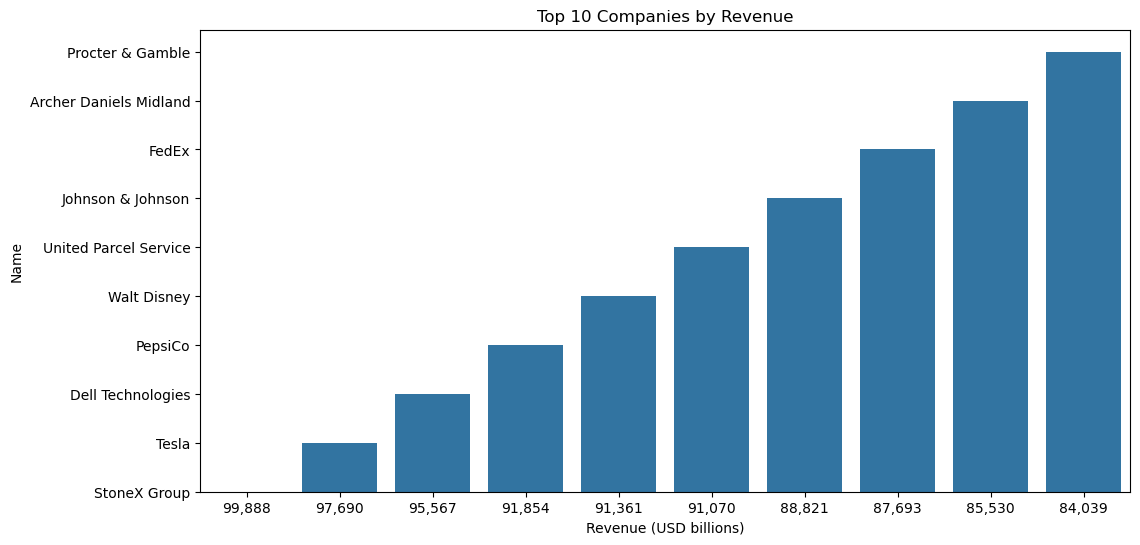

In [29]:
#Visualization
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x='Revenue (USD billions)',
    y='Name',
    data=top10
)

#ax.invert_xaxis()   # Flips graph upside down horizontally
ax.invert_yaxis()
plt.title("Top 10 Companies by Revenue")
plt.show()

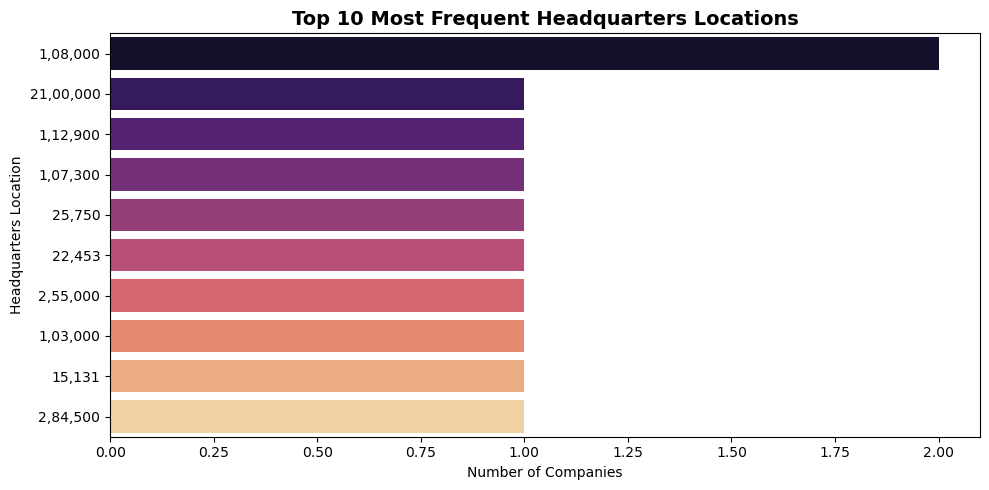

In [31]:
plt.figure(figsize=(10, 5))
top_hq = df['Headquarters'].value_counts().head(10)

# Added: hue=top_hq.index and legend=False
sns.barplot(
    x=top_hq.values, 
    y=top_hq.index, 
    hue=top_hq.index, 
    palette='magma', 
    legend=False
)
plt.title('Top 10 Most Frequent Headquarters Locations', fontsize=14, fontweight='bold')
plt.xlabel('Number of Companies')
plt.ylabel('Headquarters Location')
plt.tight_layout()
plt.show()

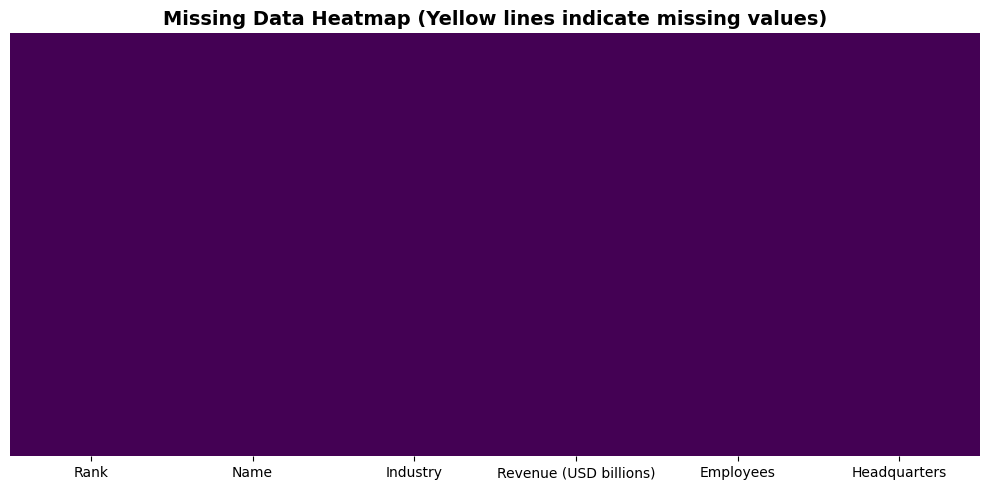

In [24]:
plt.figure(figsize=(10, 5))
# cbar=False removes the color legend since it's a simple True/False binary
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap (Yellow lines indicate missing values)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 # it shows no missing values in the companies data 